In [88]:
import numpy as np
import pylops
from pylops.utils.wavelets import ricker
import matplotlib.pyplot as plt
import ipywidgets as widgets
import segyio
import cigvis
from cigvis import colormap


petrel = colormap.cmap_to_mpl("Petrel")

# Loading seismic

In [61]:
# loading seg-y

SEGY_FILE_PATH = "./raw_data/ABL_BASE_FULL_TIME_OVERBURDENCOMP_3D_crop.sgy"
LFM_FILE_PATH = "./raw_data/TIME_LOWFREQ_3ms_ONLYWELLS_17W_500x250_N1_crop.sgy"

In [62]:
def load_seismic_cube(path, il_byte=189, xl_byte=193, verbose=True):
    """Carrega SEG-Y para cubo (nil, nxl, nt)."""
    with segyio.open(path, ignore_geometry=True) as f:
        samples = np.asarray(f.samples)
        iln = f.attributes(il_byte)[:].astype(int)
        xln = f.attributes(xl_byte)[:].astype(int)
        traces = segyio.collect(f.trace)[:]

    ntraces, nt = traces.shape
    if verbose:
        print(f"Number of traces: {ntraces}")
        print(f"Number of samples: {nt}")

    il_u, xl_u = np.unique(iln), np.unique(xln)
    il_min, il_max = il_u.min(), il_u.max()
    xl_min, xl_max = xln.min(), xln.max()

    dt = float(samples[1] - samples[0])
    dil = int(np.min(np.diff(il_u)))
    dxl = int(np.min(np.diff(xl_u)))
    if verbose:
        print(f"Inline: {il_min} - {il_max}")
        print(f"Xnline: {xl_min} - {xl_max}")
        print(f"Each sampling: \n Inline: {dil} \n Xnline: {dxl} \n Time: {dt}")

    ilines = np.arange(il_min, il_max + dil, dil)
    xlines = np.arange(xl_min, xl_max + dxl, dxl)
    nil, nxl = len(ilines), len(xlines)
    if verbose:
        print(f"Inline size: {nil}")
        print(f"Xnline size: {nxl}")

    lut = np.full((nil, nxl), -1, dtype=np.int32)
    lut[(iln - il_min)//dil, (xln - xl_min)//dxl] = np.arange(ntraces, dtype=np.int32)
    valid = lut >= 0
    if verbose:
        print(f"# Missing traces: {int((~valid).sum())}")

    cube = np.zeros((nil, nxl, nt), dtype=traces.dtype)
    cube[valid] = traces[lut[valid]]

    p5, p95 = np.nanpercentile(cube, [5, 95])
    if verbose:
        print(f"Cube shape: {cube.shape}")
        print(f"P5: {p5} and P95: {p95}")

    meta = dict(samples=samples, dt=dt, ilines=ilines, xlines=xlines,
                nil=nil, nxl=nxl, nt=nt, ntraces=ntraces,
                n_missing=int((~valid).sum()))
    return cube, meta

cube, m = load_seismic_cube(SEGY_FILE_PATH)
lfm, m_lfm = load_seismic_cube(LFM_FILE_PATH)


Number of traces: 243307
Number of samples: 1614
Inline: 970 - 1436
Xnline: 1650 - 2170
Each sampling: 
 Inline: 1 
 Xnline: 1 
 Time: 3.0
Inline size: 467
Xnline size: 521
# Missing traces: 0
Cube shape: (467, 521, 1614)
P5: -128886.0625 and P95: 123214.375
Number of traces: 243307
Number of samples: 1614
Inline: 970 - 1436
Xnline: 1650 - 2170
Each sampling: 
 Inline: 1 
 Xnline: 1 
 Time: 3.0
Inline size: 467
Xnline size: 521
# Missing traces: 0
Cube shape: (467, 521, 1614)
P5: 0.0 and P95: 8461.9296875


In [63]:
def plot_inline_section(cube, meta, inline_idx=None, clip=4, cmap=None):
    """Plota secao inline do cubo (nil, nxl, nt)."""
    if cmap is None:
        cmap = petrel
    nil = cube.shape[0]
    if inline_idx is None:
        inline_idx = nil // 2
    p5, p95 = np.nanpercentile(cube, [5, 95])
    plt.figure(figsize=(7, 5))
    plt.imshow(
        cube[inline_idx].T,
        aspect="auto",
        cmap=cmap,
        vmin=p5 * clip,
        vmax=p95 * clip,
    )
    plt.title(f"Iline {inline_idx} / il {meta['ilines'][inline_idx]}")
    plt.xlabel("Xline")
    plt.ylabel("Time sample")


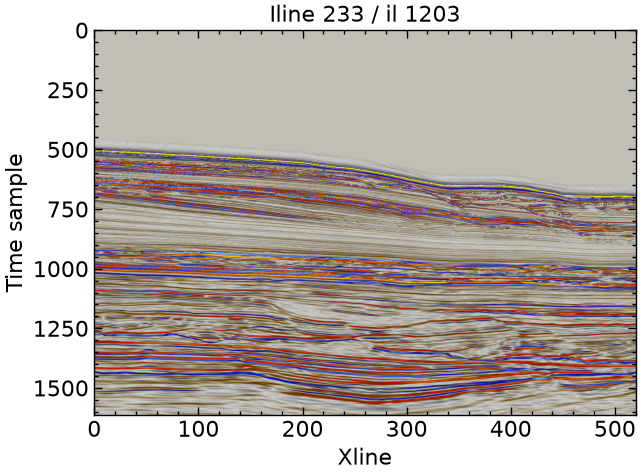

In [89]:
plot_inline_section(cube, m)


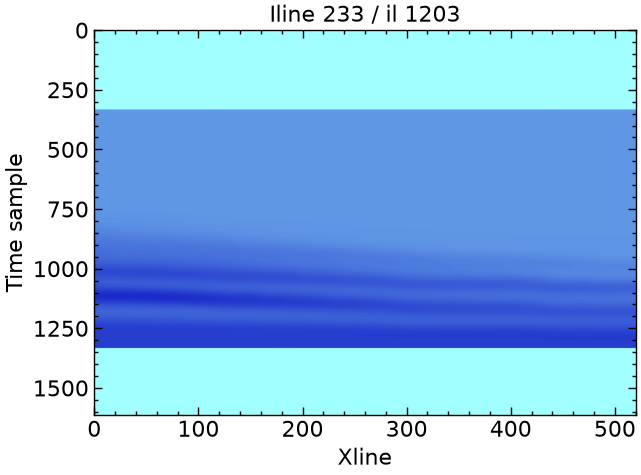

In [90]:
plot_inline_section(lfm, m_lfm)


# Wavelet

In [66]:
def estimate_statistical_wavelet(cube, samples, dt, t_win=(2000, 4000), nfft=None, nt_wav=33):
    """Estima wavelet estatistica (fase zero) a partir do espectro medio.

    Retorna wav, spec_norm, f_axis, t_axis.
    dt em ms (como em m['dt']); eixos de freq em Hz e tempo em s.
    """
    dt_s = float(dt) / 1000.0
    idx0 = int(np.argmin(np.abs(samples - t_win[0])))
    idx1 = int(np.argmin(np.abs(samples - t_win[1])))
    print(f"Indice of sample {t_win[0]}: {idx0}")
    print(f"Indice of sample {t_win[1]}: {idx1}")

    panel = cube[:, :, idx0:idx1].reshape(-1, idx1 - idx0)
    nw = panel.shape[1]
    if nfft is None:
        nfft = int(2 ** np.ceil(np.log2(nw)))

    fft_tr = np.fft.fft(panel, nfft, axis=-1)
    # Espectro medio de amplitude sobre os tracos (fase zero, so usa |FFT|)
    spec = np.mean(np.abs(fft_tr), axis=0)

    f_axis = np.fft.fftfreq(nfft, d=dt_s)[:nfft // 2]
    spec_n = spec[:nfft // 2] / np.max(spec[:nfft // 2])

    wav = np.real(np.fft.ifft(spec)[:nt_wav])
    wav = np.concatenate((np.flipud(wav[1:]), wav), axis=0)
    wav = wav / np.max(np.abs(wav))

    t_axis = np.arange(-nt_wav + 1, nt_wav) * dt_s
    return wav, spec_n, f_axis, t_axis


def plot_wavelet(t_axis, wav, f_axis, spec):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(t_axis, wav, lw=2.0)
    axes[0].set_title("Time")
    axes[0].grid()
    axes[1].plot(f_axis, spec, lw=2.0)
    axes[1].set_title("Frequency")
    axes[1].grid()
    plt.show()


NT_WAV = 33


In [67]:
wav, spec, f_axis, t_axis = estimate_statistical_wavelet(
    cube, m["samples"], m["dt"], t_win=(2000, 4000), nfft=1024, nt_wav=NT_WAV
)
print(f"wav: {wav.shape}, spec: {spec.shape}")


Indice of sample 2000: 667
Indice of sample 4000: 1333
wav: (65,), spec: (512,)


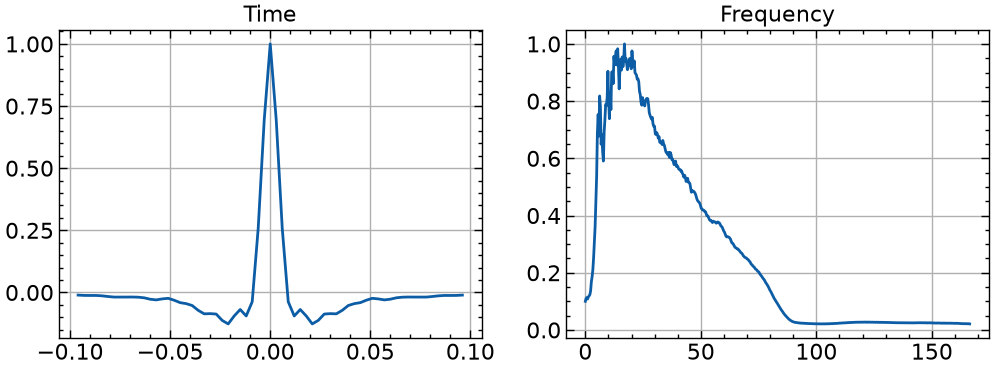

In [68]:
plot_wavelet(t_axis, wav, f_axis, spec)


# Inversão Acústica (GLI)

In [70]:
def run_gli_acoustic(
    sein,
    lfm,
    wav,
    eps_i=1e-1,
    eps_r=5e-1,
    damp=1e-1,
    iter_lim=100,
    explicit=False,
):
    """
    sein : ndarray
        Dado sismico observado (empilhado), shape (nt0,) ou (nt0, nx, ny).
        Cubo do loader e (nil, nxl, nt) -> usar sein = cube.transpose(2, 0, 1).
    lfm : ndarray
        Modelo de baixa frequencia de impedancia acustica, mesmo shape de sein.
    wav : ndarray
        Wavelet estimada, dominio do tempo.
    eps_i : float
        Peso de damping (regularizacao Tikhonov sobre o modelo).
    eps_r : float
        Peso de blockiness (regularizacao sobre a derivada do modelo).
    damp : float
        Damping interno do solver lsqr.
    iter_lim : int
        Numero maximo de iteracoes do solver.
    explicit : bool
        Se True, usa solver denso (lstsq). Se False, usa iterativo (lsqr).

    Retorna
    -------
    aiinv : ndarray
        Impedancia acustica invertida.
    dres : ndarray
        Residuo entre dado observado e dado reproduzido pelo modelo invertido.
    """
    mback = np.log(lfm)

    minv, dres = pylops.avo.poststack.PoststackInversion(
        sein, wav, m0=mback,
        explicit=explicit, epsI=eps_i, epsR=eps_r,
        damp=damp, iter_lim=iter_lim,
    )

    aiinv = np.exp(minv)
    return aiinv, dres


In [82]:
# Exemplo (cubo inteiro e pesado: rode num subset primeiro):
sein = cube.transpose(2, 0, 1)  # (nt, nil, nxl)
lfm_t = lfm.transpose(2, 0, 1)

floor = float(np.percentile(lfm_t[lfm_t > 0], 1)) # ~4570
lfm_safe = np.maximum(lfm_t, floor)

C:\Users\Icarl\AppData\Local\Temp\ipykernel_23892\1597742534.py:45: RuntimeWarning: overflow encountered in exp
  aiinv = np.exp(minv)


In [97]:
aiinv, dres = run_gli_acoustic(sein[:, :50, :50], lfm_safe[:, :50, :50], wav)

C:\Users\Icarl\AppData\Local\Temp\ipykernel_23892\1597742534.py:45: RuntimeWarning: overflow encountered in exp
  aiinv = np.exp(minv)


Text(0.5, 1.0, 'AI inv')

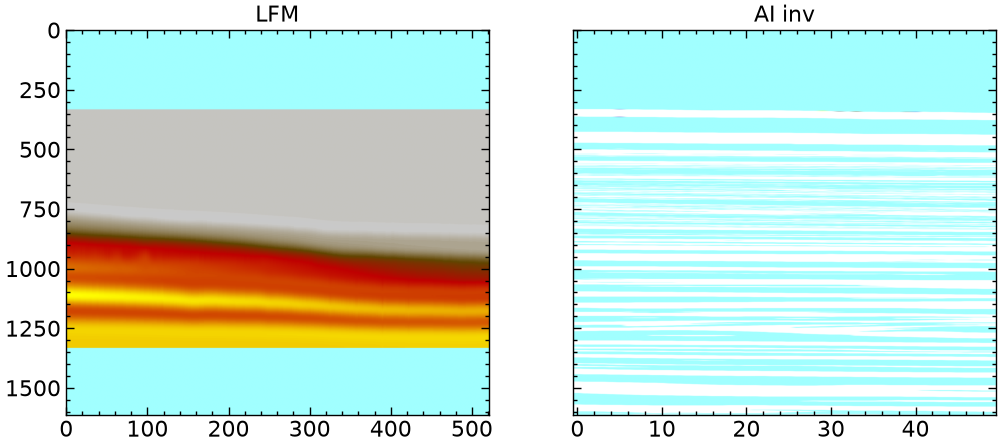

In [102]:
k = 25

fig, ax = plt.subplots(1, 2, figsize=(12,5), sharey=True)
ax[0].imshow(lfm_t[:, k, :], aspect="auto", cmap=petrel); ax[0].set_title("LFM")
ax[1].imshow(aiinv[:, k, :], aspect="auto", cmap=petrel); ax[1].set_title("AI inv")

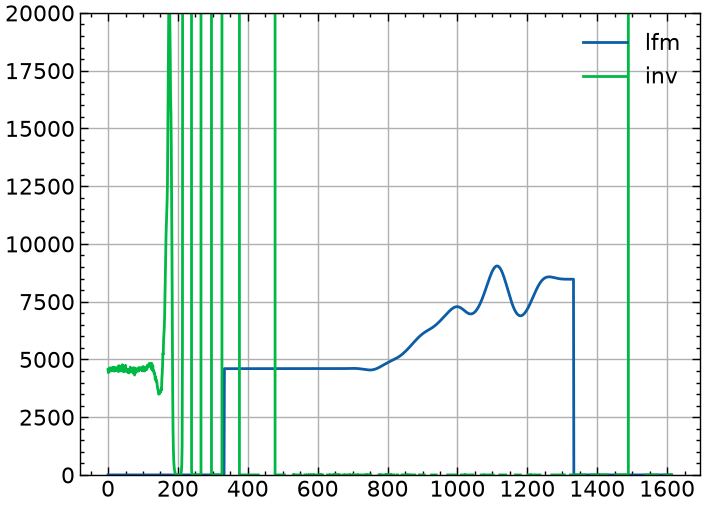

In [104]:
i, j = 25, 25
plt.figure()
plt.plot(lfm_t[:, i, j], label="lfm")
plt.plot(aiinv[:, i, j], label="inv")
plt.ylim(0, 20000)
plt.legend(); plt.grid()

# Inversão Elástica (GLI)